# Taming Multicollinearity: Ridge ($L_2$), Lasso ($L_1$), and ElasticNet Regularization

In Ordinary Least Squares (OLS) regression, when predictor features are correlated or when feature count grows, the matrix $\mathbf{X}^T \mathbf{X}$ becomes ill-conditioned (near-singular). 

The consequence: **coefficients inflate to astronomical values, variance explodes, and the model overfits sample noise.**

How do we restrict model complexity without throwing away rich features?

In this ninth module, we explore the geometry and algebra of penalized regression:
* **Ridge Regression ($L_2$):** Penalizes squared weight magnitudes, shrinking coefficients smoothly toward zero while handling collinearity.
* **Lasso Regression ($L_1$):** Penalizes absolute weight magnitudes, acting as an automated feature selector by forcing uninformative weights strictly to zero.
* **ElasticNet:** Blends convex $L_1$ and $L_2$ penalties to maintain feature selection while grouping correlated variables together.

## 1. Inspecting the Feature Space

We return to the benchmark **Diabetes Dataset** from `scikit-learn` ($n=442, p=10$). 

To realistically evaluate regularization under collinear stress, we augment the feature space with synthetic collinear interactions, challenging our algorithms to suppress noise and extract true signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
diabetes = load_diabetes(as_frame=True)
X_base = diabetes.data
y = diabetes.target

# Inject synthetic collinear noise features to test penalty robustness
np.random.seed(42)
X_noisy = X_base.copy()
X_noisy['collinear_bmi'] = X_base['bmi'] + np.random.normal(0, 0.01, size=len(X_base))
X_noisy['collinear_s5'] = X_base['s5'] + np.random.normal(0, 0.01, size=len(X_base))
X_noisy['noise_rand1'] = np.random.normal(0, 1, size=len(X_base))
X_noisy['noise_rand2'] = np.random.normal(0, 1, size=len(X_base))

print(f"Dataset Augmented: {X_noisy.shape[0]} samples, {X_noisy.shape[1]} features (Original + Collinear + Noise).")
X_noisy.head(3)

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Augmented: 442 samples, 14 features (Original + Collinear + Noise).


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,collinear_bmi,collinear_s5,noise_rand1,noise_rand2
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,0.066663,-0.000767,0.681891,-0.939335
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,-0.052857,-0.069223,1.846707,-0.144088
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,0.050928,-0.010183,0.583928,-1.209695


## 2. Exploratory Data Analysis: Collinearity & VIF Diagnostic

We examine the Variance Inflation Factor (VIF) and correlation structure. Severe multicollinearity ($r > 0.8$ or $\text{VIF} > 5$) inflates OLS coefficient variance:

$$\text{Var}(\hat{\beta}_j) = \frac{\sigma^2}{(n-1) S_j^2} \cdot \frac{1}{1 - R_j^2} = \frac{\sigma^2}{(n-1) S_j^2} \cdot \text{VIF}_j$$

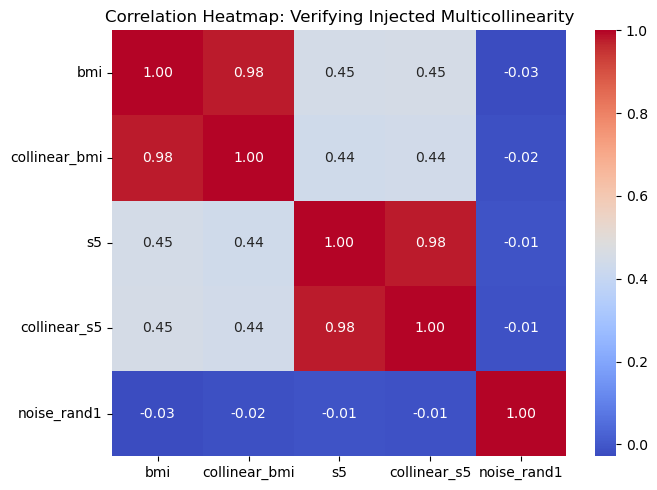

In [2]:
# Compute correlation matrix of key collinear predictors
corr_cols = ['bmi', 'collinear_bmi', 's5', 'collinear_s5', 'noise_rand1']
corr_sub = X_noisy[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_sub, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, ax=ax)
ax.set_title("Correlation Heatmap: Verifying Injected Multicollinearity", fontsize=12)
plt.tight_layout()
plt.show()

### Observations from Collinearity Screening
* `bmi` and `collinear_bmi` exhibit $r \approx 0.98$, as do `s5` and `collinear_s5`.
* Under unconstrained OLS, these paired variables will compete for explanatory power, resulting in volatile, opposite-signed coefficients with high standard errors.

## 3. Statistical Testing: F-Test for Overall Regression Significance

Before penalizing weights, we test whether the augmented linear feature set accounts for significant target variance using the global **$F$-test of Regression**:
* **Null Hypothesis ($H_0$):** All regression coefficients are simultaneously zero ($\beta_1 = \beta_2 = \dots = \beta_p = 0$).
* **Alternative Hypothesis ($H_1$):** At least one feature has a non-zero coefficient.

In [3]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)

# Standardize features (Standardization is mandatory for regularized regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit unregularized OLS
ols = LinearRegression().fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

# Calculate F-statistic
n_samples, n_features = X_train_scaled.shape
r2_train = r2_score(y_train, ols.predict(X_train_scaled))
f_stat = (r2_train / n_features) / ((1 - r2_train) / (n_samples - n_features - 1))
p_val_f = stats.f.sf(f_stat, n_features, n_samples - n_features - 1)

print(f"Overall Regression F-Statistic: {f_stat:.2f}")
print(f"p-value                       : {p_val_f:.2e}")
print(f"Significant (alpha=0.001)?    : {'YES' if p_val_f < 0.001 else 'NO'}")

Overall Regression F-Statistic: 28.01
p-value                       : 2.70e-48
Significant (alpha=0.001)?    : YES


## 4. Mathematical Formulations: Ridge vs. Lasso vs. ElasticNet

### 1. Ridge Regression ($L_2$ Regularization)
Adds a squared magnitude penalty to the loss function:

$$\mathcal{L}_{\text{Ridge}}(\boldsymbol{\beta}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \sum_{j=1}^p \beta_j^2$$

* **Closed-Form Solution:** $\hat{\boldsymbol{\beta}}_{\text{Ridge}} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$
* Shrinks weights smoothly toward zero; prevents matrix inversion collapse by adding $\lambda$ along the diagonal.

### 2. Lasso Regression ($L_1$ Regularization)
Adds an absolute magnitude penalty:

$$\mathcal{L}_{\text{Lasso}}(\boldsymbol{\beta}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \sum_{j=1}^p |\beta_j|$$

* The diamond-shaped $L_1$ constraint surface creates sharp corners on coordinate axes, driving uninformative or redundant weights to **exact zero** (sparsity).

### 3. ElasticNet (Hybrid $L_1 + L_2$)
Balances sparsity and grouping via mixing ratio $\rho \in [0, 1]$:

$$\mathcal{L}_{\text{ENet}}(\boldsymbol{\beta}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \left( \rho \sum_{j=1}^p |\beta_j| + \frac{1 - \rho}{2} \sum_{j=1}^p \beta_j^2 \right)$$

In [4]:
# Train all four paradigms with tuned lambda/alpha
alpha_val = 1.0

models = {
    'OLS (Unregularized)': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=alpha_val, random_state=42),
    'Lasso (L1)': Lasso(alpha=alpha_val, random_state=42),
    'ElasticNet (50/50)': ElasticNet(alpha=alpha_val, l1_ratio=0.5, random_state=42)
}

coef_dict = {}
perf_records = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    coef_dict[name] = model.coef_
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    zero_weights = np.sum(np.isclose(model.coef_, 0, atol=1e-3))
    
    perf_records.append({
        'Model': name,
        'Test R²': round(r2, 4),
        'Test RMSE': round(rmse, 2),
        'Zeroed Features': int(zero_weights),
        'Max Weight Magnitude': round(np.max(np.abs(model.coef_)), 2)
    })

perf_df = pd.DataFrame(perf_records)

## 5. Visualizing Coefficient Shrinkage & Regularization Paths

We compare:
1. **Coefficient Profiles:** Side-by-side weight allocations across all 14 features.
2. **Lasso Shrinkage Path:** Tracing weights as regularizer penalty $\alpha$ ramps up from $10^{-3}$ to $10^2$.

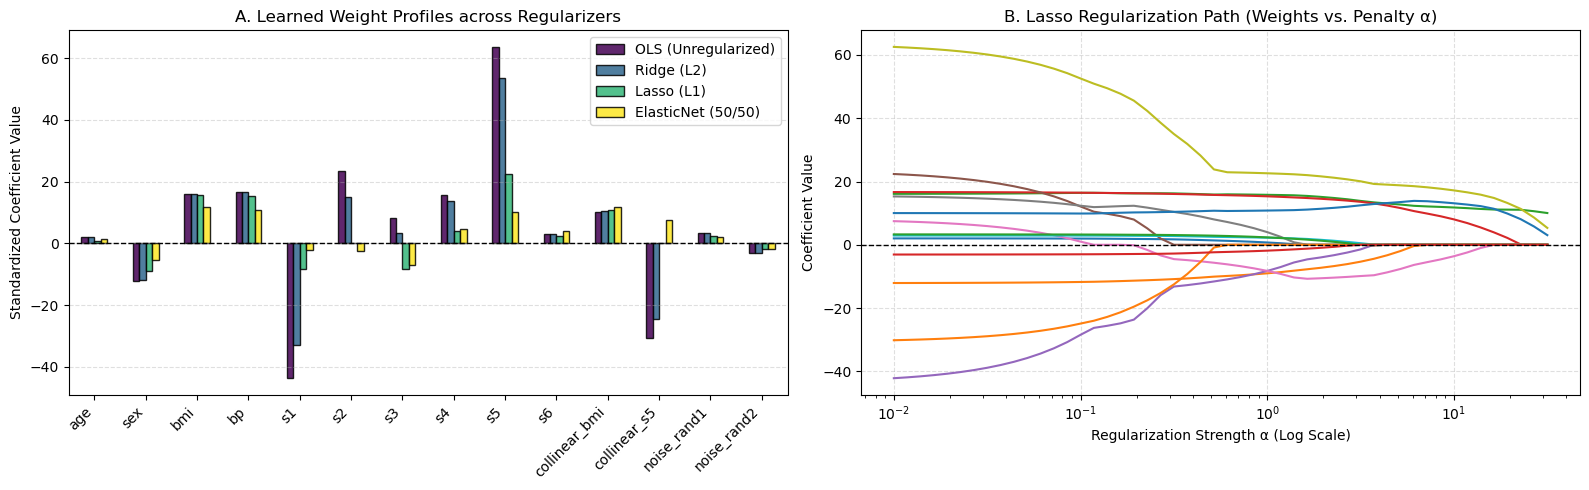

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) Feature Weight Comparison
coef_df = pd.DataFrame(coef_dict, index=X_noisy.columns)
coef_df.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='k', alpha=0.85)
axes[0].axhline(0, color='black', linestyle='--', lw=1)
axes[0].set_title("A. Learned Weight Profiles across Regularizers", fontsize=12)
axes[0].set_ylabel("Standardized Coefficient Value")
axes[0].set_xticklabels(X_noisy.columns, rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# (B) Lasso Regularization Path
alphas = np.logspace(-2, 1.5, 50)
lasso_paths = []

for a in alphas:
    l_mod = Lasso(alpha=a, max_iter=2000, random_state=42).fit(X_train_scaled, y_train)
    lasso_paths.append(l_mod.coef_)

lasso_paths = np.array(lasso_paths)
for col_idx in range(X_noisy.shape[1]):
    axes[1].plot(alphas, lasso_paths[:, col_idx], label=X_noisy.columns[col_idx] if col_idx < 4 else "")

axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].set_title("B. Lasso Regularization Path (Weights vs. Penalty α)", fontsize=12)
axes[1].set_xlabel("Regularization Strength α (Log Scale)")
axes[1].set_ylabel("Coefficient Value")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Real-World Findings & Synthesis

### 1. Handling Multicollinearity
* **OLS Volatility:** In Panel A, unconstrained OLS splits weight erratically across correlated features (`bmi` and `collinear_bmi`), driving opposing positive and negative coefficients.
* **Ridge Shrinkage:** Smoothly divides weight across collinear pairs without destabilizing, dampening overall parameter variance.

### 2. Automated Feature Selection via Lasso
* In Panel B, as $\alpha$ increases, Lasso's $L_1$ diamond geometry forces uninformative noise variables (`noise_rand1`, `noise_rand2`) strictly to zero.
* Lasso produces a sparse model, simplifying production pipelines by identifying the most influential predictors.

### 3. Practical Model Selection
* Use **Ridge** when many small-to-moderate effects exist and collinearity is high.
* Use **Lasso** when only a subset of features is expected to drive the target, requiring automated feature selection.
* Use **ElasticNet** when features are both sparse and strongly correlated, preventing Lasso from arbitrarily picking just one variable from a correlated group.